
### Objectiu del departament d'Anàlisi de Perfil Client:

> Quines combinacions de característiques demogràfiques (com edat, nivell educatiu i ocupació) són més comunes entre els clients que utilitzen múltiples productes financers del banc: loan, hipoteca, dipòsit?

### Llibreries i càrrega de dades

In [130]:
"""Libreries que poden ser necessàries"""

# Manejo de datos
import pandas as pd                 # Análisis y manipulación de datos en tablas
import numpy as np                  # Cálculos numéricos y matrices
import os                           # Gestión de rutas de archivos

# Visualización de datos
import matplotlib.pyplot as plt     # Gráficos básicos en 2D
import seaborn as sns               # Gráficos estadísticos mejorados
import plotly.express as px         # Gráficos interactivos simplificados
import plotly.graph_objects as go   # Control avanzado de gráficos en Plotly
import plotly.io as pio             # Interfaz de entrada/salida de Plotly
import squarify                     # Visualización de diagramas de "treemap"
from plottable import Table         # Visualización de tablas
import matplotlib.colors as mcolors # Colores y mapas de colores

# Clustering y agrupamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes


In [131]:
# %pip install plottable
# %pip install kmodes


In [132]:
df = pd.read_csv("../Data/df_250526.csv")

Paleta de colors

In [133]:
custom_palette = ["#AABBC8", "#2CCED1", "#5F6F81", "#DCE3EA", "#2E2F36"]  
sns.set_palette(sns.color_palette(custom_palette))

### Extracte KPIs

In [134]:

# Variables 
contactados   = df.nunique().id                                     # Número total de clientes contactados
suscribieron  = df[df['deposit'] == True].nunique().id             # Número de clientes que suscribieron 
duracion_llam = df[df['deposit'] == True].duration.sum()           # Duración de llamadas a suscriptores
llam_telf = df[df['contact'] == 'telephone']['campaign'].sum()      # Número de llamadas realizadas por teléfono
llam_cell = df[df['contact'] == 'cellular']['campaign'].sum()       # Número de llamadas realizadas por movil
llam = df['campaign'].sum()                                         # Número total de llamadas
contatos_previos_sus = df[df['deposit'] == True]['previous'].sum() # Número de contactos previos a suscriptores
suscribieron_por_mes = df[df['deposit'] == True].groupby('month').count()['deposit']  # Suscriptores en el mes
contactos_por_mes = df.groupby('month').count()['deposit']          # clientes contactados en el mes      
conversion_por_mes = suscribieron_por_mes / contactos_por_mes       # conversión por mes


# Prints
print("El número total de clientes contactados es:",contactados)
print("El número de suscriptores es:",suscribieron)
print("La duración total de las llamadas a suscriptores es:",duracion_llam)
print("El número de llamadas realizadas a teléfono fijo es: ", llam_telf)
print("El número de llamadas realizadas a móvil es: ", llam_cell)
print("El número total de llamadas realizadas es: ", llam)
print("El número total de contactos previos de los suscriptores es:", contatos_previos_sus)
print("La conversión por mes es: ", conversion_por_mes)

El número total de clientes contactados es: 26180
El número de suscriptores es: 12499
La duración total de las llamadas a suscriptores es: 6763175
El número de llamadas realizadas a teléfono fijo es:  5399
El número de llamadas realizadas a móvil es:  45476
El número total de llamadas realizadas es:  65801
El número total de contactos previos de los suscriptores es: 14668
La conversión por mes es:  month
Apr    0.630156
Aug    0.456259
Dec    0.902344
Feb    0.576944
Jan    0.409548
Jul    0.413754
Jun    0.446554
Mar    0.903374
May    0.334334
Nov    0.426036
Oct    0.838816
Sep    0.844941
Name: deposit, dtype: float64


In [135]:
#KPIs
kpi1 = suscribieron/contactados          # porcentaje de conversión a depósito
kpi2 = duracion_llam/suscribieron        # promedio de duración de llamadas a suscriptores
kpi3_tel = llam_telf/llam                # porcentaje de llamadas a teléfono
kpi3_cell = llam_cell/llam               # porcentaje de llamadas a móvil
kpi3 = (llam_telf+llam_cell)/llam        # porcentaje de llamadas a teléfono o móvil
kpi4 = contatos_previos_sus/suscribieron # promedio de contactos previos a suscriptores
kpi5 = conversion_por_mes.idxmax()       # mes con mayor tasa de conversión
kpi5_tasa = conversion_por_mes.max()     # tasa de conversión del mes con mayor tasa de conversión




# Prints
print("KPI 1: El porcentaje de conversión a depósito es ",kpi1*100,"%")
print("KPI 2: La duración media de las llamadas a suscriptoreses",kpi2)
# print("KPI 3: El porcentaje de llamadas realizadas por teléfono o móvil es ",kpi3*100,"%")
print("KPI 3.1: El porcentaje de llamadas realizadas por teléfono fijo es ",kpi3_tel*100,"%")
print("KPI 3.2: El porcentaje de llamadas realizadas por teléfono móvil es ",kpi3_cell*100,"%")
print("KPI 4: El porcentaje de contactos previos a suscriptores es ",kpi4)
print("KPI 5: El mes amb millor conversió ha sigut", kpi5, "amb una taxa de conversió de", kpi5_tasa)

KPI 1: El porcentaje de conversión a depósito es  47.74255156608098 %
KPI 2: La duración media de las llamadas a suscriptoreses 541.0972877830227
KPI 3.1: El porcentaje de llamadas realizadas por teléfono fijo es  8.205042476558107 %
KPI 3.2: El porcentaje de llamadas realizadas por teléfono móvil es  69.11141168067356 %
KPI 4: El porcentaje de contactos previos a suscriptores es  1.1735338827106168
KPI 5: El mes amb millor conversió ha sigut Mar amb una taxa de conversió de 0.9033742331288344


# Anàlisi 

### Elbow method para encontrar k óptimo
Calculo el costo para diferentes valores de l entre 2 - 9 (inclusive)

https://es.wikipedia.org/wiki/M%C3%A9todo_del_codo_(agrupamiento)
El método consiste en graficar la variación explicada en función del número de conglomerados y elegir el codo de la curva como el número de conglomerados a utilizar. Utilizar el "codo" o la "rodilla de una curva" como punto de corte es un método común en la optimización matemática para elegir aquel punto a partir del cual los rendimientos decrecientes ya no justifican el costo adicional.

En este caso, el codo está en el 4.

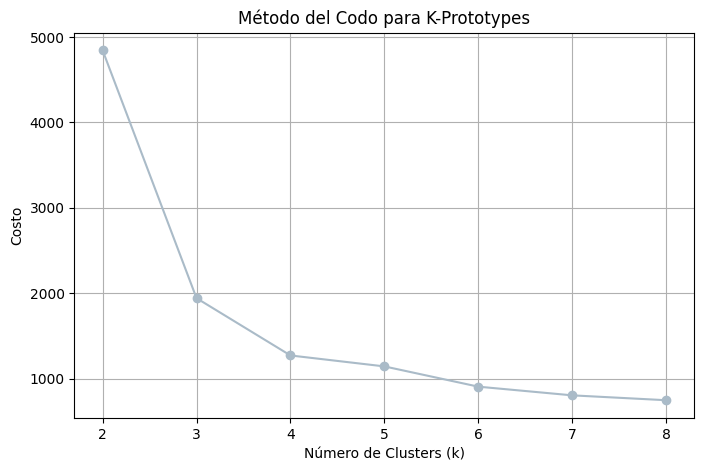

In [136]:
costs = []
ks = list(range(2, 9))

for k in ks:
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0)
    clusters = kproto.fit_predict(X_proto, categorical=[1, 2, 3])
    costs.append(kproto.cost_)

# Graficar la curva del codo
plt.figure(figsize=(8, 5))
plt.plot(ks, costs, marker='o')
plt.title('Método del Codo para K-Prototypes')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Costo')
plt.grid(True)
plt.show()

## Càlcul per a clients que no han contractat res

In [137]:
# Número de clients que van suscriure, tenen prèstec i una hipoteca 
df_0contractats = df[(df['deposit'] == False) & (df['loan'] == False) & (df['housing'] == False)] 

df_0contractats_numero = df_0contractats.nunique().id 
print("El número de clientes que no suscribieron, no tienen préstamo ni hipoteca es:", df_0contractats_numero)


# Agrupem el dataframe per la combinació de les característiques demogràfiques 
df_0contractats = df_0contractats.groupby(['job', 'marital', 'education'])


# Creem una taula per al càlcul de conversions
taula_pefils_0contractats = []

# Recorrem la taula calculant la conversió de cada grup
for (feina, estat_civil, educacio), grup in df_0contractats:
    numero = grup.nunique().id

    # Afegim cada resultat a la taula
    taula_pefils_0contractats.append({
        'job': feina,
        'marital': estat_civil,
        'education': educacio,
        'número': numero,
    })

# Convertim la taula de conversió en un dataframe 
taula_pefils_0contractats = pd.DataFrame(taula_pefils_0contractats)

# taula_pefils = taula_pefils.set_index(['feina', 'estat_civil', 'educació'])  # Establim l'índex de la taula

# Ordenem per 
taula_pefils_0contractats = taula_pefils_0contractats.sort_values(by='número', ascending=False)  # Ordenem la taula per número de persones

# Reordenem les columnes de la taula

taula_pefils_0contractats.head(15)  # Mostrem les primeres 15 files de la taula

El número de clientes que no suscribieron, no tienen préstamo ni hipoteca es: 4928


,job,marital,education,número
48,management,married,tertiary,579
51,management,single,tertiary,340
95,technician,married,secondary,314
98,technician,single,secondary,204
14,blue-collar,married,primary,203
15,blue-collar,married,secondary,190
4,admin.,married,secondary,185
96,technician,married,tertiary,129
8,admin.,single,secondary,122
44,management,divorced,tertiary,118


## Càlcul per a clients que han contractat només un producte


In [138]:
# Crear una nova columna temporal que compta quants productes ha contractat el client
df['productes_contractats'] = df[['deposit', 'loan', 'housing']].sum(axis=1)

# Filtrar els clients que n'han contractat exactament un
df_1contractats = df[df['productes_contractats'] == 1].copy()


df_1contractats_numero = df_1contractats.nunique().id 
print("El número de clientes que o bien suscribieron, o bien tienen préstamo o hipoteca es:", df_1contractats_numero)


# Agrupem el dataframe per la combinació de les característiques demogràfiques 
df_1contractats = df_1contractats.groupby(['job', 'marital', 'education'])


# Creem una taula per al càlcul de conversions
taula_pefils_1contractats = []

# Recorrem la taula calculant la conversió de cada grup
for (feina, estat_civil, educacio), grup in df_1contractats:
    numero = grup.nunique().id

    # Afegim cada resultat a la taula
    taula_pefils_1contractats.append({
        'job': feina,
        'marital': estat_civil,
        'education': educacio,
        'número': numero,
    })

# Convertim la taula de conversió en un dataframe 
taula_pefils_1contractats = pd.DataFrame(taula_pefils_1contractats)

# taula_pefils = taula_pefils.set_index(['feina', 'estat_civil', 'educació'])  # Establim l'índex de la taula

# Ordenem per 
taula_pefils_1contractats = taula_pefils_1contractats.sort_values(by='número', ascending=False)  # Ordenem la taula per número de persones

# Reordenem les columnes de la taula

taula_pefils_1contractats.head(15)  # Mostrem les primeres 15 files de la taula


El número de clientes que o bien suscribieron, o bien tienen préstamo o hipoteca es: 14777


,job,marital,education,número
49,management,married,tertiary,1566
53,management,single,tertiary,1085
16,blue-collar,married,secondary,866
5,admin.,married,secondary,760
102,technician,married,secondary,753
15,blue-collar,married,primary,706
82,services,married,secondary,532
106,technician,single,secondary,501
9,admin.,single,secondary,455
60,retired,married,secondary,404


## Càlcul per a clients que han contractat més d'un producte


In [139]:
# Filtrar els clients que n'han contractat més d’un (>=2)
df_mes_dun_contractat = df[df['productes_contractats'] >= 2].copy()

# Eliminar la columna temporal si no cal
df_mes_dun_contractat.drop(columns='productes_contractats', inplace=True)



df_mes_dun_contractat_numero = df_mes_dun_contractat.nunique().id 
print("El número de clientes que contrataron dos o más productes entre suscribirse, préstamo o hipoteca es:", df_mes_dun_contractat_numero)


# Agrupem el dataframe per la combinació de les característiques demogràfiques 
df_mes_dun_contractat = df_mes_dun_contractat.groupby(['job', 'marital', 'education'])


# Creem una taula per al càlcul de conversions
taula_df_mes_dun_contractat = []

# Recorrem la taula calculant la conversió de cada grup
for (feina, estat_civil, educacio), grup in df_mes_dun_contractat:
    numero = grup.nunique().id

    # Afegim cada resultat a la taula
    taula_df_mes_dun_contractat.append({
        'job': feina,
        'marital': estat_civil,
        'education': educacio,
        'número': numero,
    })

# Convertim la taula de conversió en un dataframe 
taula_df_mes_dun_contractat = pd.DataFrame(taula_df_mes_dun_contractat)

# taula_pefils = taula_pefils.set_index(['feina', 'estat_civil', 'educació'])  # Establim l'índex de la taula

# Ordenem per 
taula_df_mes_dun_contractat = taula_df_mes_dun_contractat.sort_values(by='número', ascending=False)  # Ordenem la taula per número de persones

# Reordenem les columnes de la taula

taula_df_mes_dun_contractat.head(15)  # Mostrem les primeres 15 files de la taula



El número de clientes que contrataron dos o más productes entre suscribirse, préstamo o hipoteca es: 6475


,job,marital,education,número
15,blue-collar,married,secondary,647
46,management,married,tertiary,554
90,technician,married,secondary,447
49,management,single,tertiary,405
4,admin.,married,secondary,356
14,blue-collar,married,primary,327
8,admin.,single,secondary,298
72,services,married,secondary,284
93,technician,single,secondary,264
19,blue-collar,single,secondary,257


## Verificació dels tres grups

In [140]:
print("El número de clientes que no suscribieron, no tienen préstamo ni hipoteca es:", df_0contractats_numero)
print("El número de clientes que o bien suscribieron, o bien tienen préstamo o hipoteca es:", df_1contractats_numero)
print("El número de clientes que contrataron dos o más productes entre suscribirse, préstamo o hipoteca es:", df_mes_dun_contractat_numero)

print("La suma de los anteriores es", df_0contractats_numero + df_1contractats_numero + df_mes_dun_contractat_numero)


print("El total de clientes contactados es", df.nunique().id)


El número de clientes que no suscribieron, no tienen préstamo ni hipoteca es: 4928
El número de clientes que o bien suscribieron, o bien tienen préstamo o hipoteca es: 14777
El número de clientes que contrataron dos o más productes entre suscribirse, préstamo o hipoteca es: 6475
La suma de los anteriores es 26180
El total de clientes contactados es 26180


## Clusters dels 3 grups 

## Hi ha diferència?